Filter Used: i


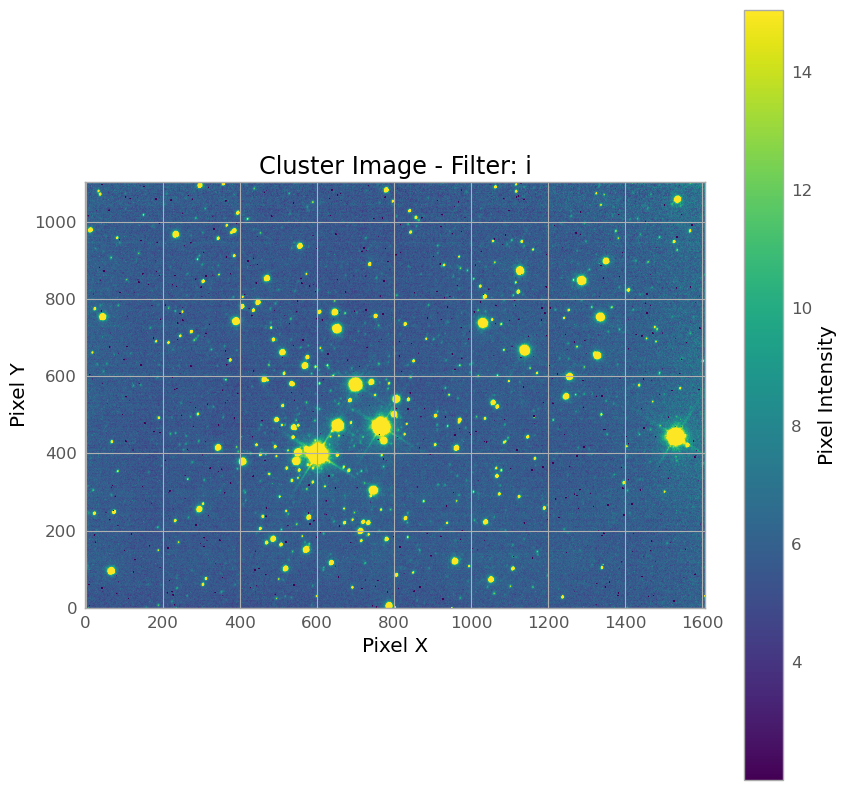

In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import astropy_mpl_style, ZScaleInterval, ImageNormalize
file_path = 'Berk_i.wcs.proc (1).fits' 
hdul = fits.open(file_path)
image_data = hdul[0].data
header = hdul[0].header
print(f"Filter Used: {header.get('FILTER', 'N/A')}") 
norm = ImageNormalize(image_data, interval=ZScaleInterval())

plt.style.use(astropy_mpl_style)
plt.figure(figsize=(10, 10))
plt.imshow(image_data, cmap='viridis', norm=norm, origin='lower')

plt.colorbar(label='Pixel Intensity')
plt.title(f"Cluster Image - Filter: {header.get('FILTER', 'Unknown')}")
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()

hdul.close()

In [5]:
!pip install astroquery pandas
from astroquery.gaia import Gaia
import pandas as pd
import sys

# 1. Define your query (The instructions for Gaia)
# We are asking for stars in a 0.8 degree circle around your cluster coordinates [cite: 31, 116]
sql_query = """
SELECT 
    source_id, ra, dec, 
    parallax, pmra, pmdec, 
    phot_g_mean_mag, bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE 
    CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', 0.5, 67.4, 0.8)
    ) = 1
    AND parallax > 0
    AND parallax_over_error > 5
    AND ruwe < 1.4
    AND phot_g_mean_mag < 19
"""

# 2. Launch the job (This sends the request to the Gaia archive)
print("Querying Gaia database... please wait.")
job = Gaia.launch_job_async(sql_query)

# 3. Get the results into a table format
results = job.get_results()
print(f"Successfully retrieved {len(results)} stars!")

# 4. Save to CSV
# This allows you to open the data in Excel or use it in the next step
df_gaia = results.to_pandas()
df_gaia.to_csv('gaia_results.csv', index=False)

print("Gaia results saved as 'gaia_results.csv'.")

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 7.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.1 MB 6.1 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.1 MB 3.5 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.1 MB 4.0 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.1 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.1 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.1 MB 4.0 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 3.7 MB/s eta 0:00:02
   -------------------------- ------------- 7.3/11.1 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.1 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.1 MB 3.9 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.1 MB 3.9 MB/s eta 0:00:01
   --

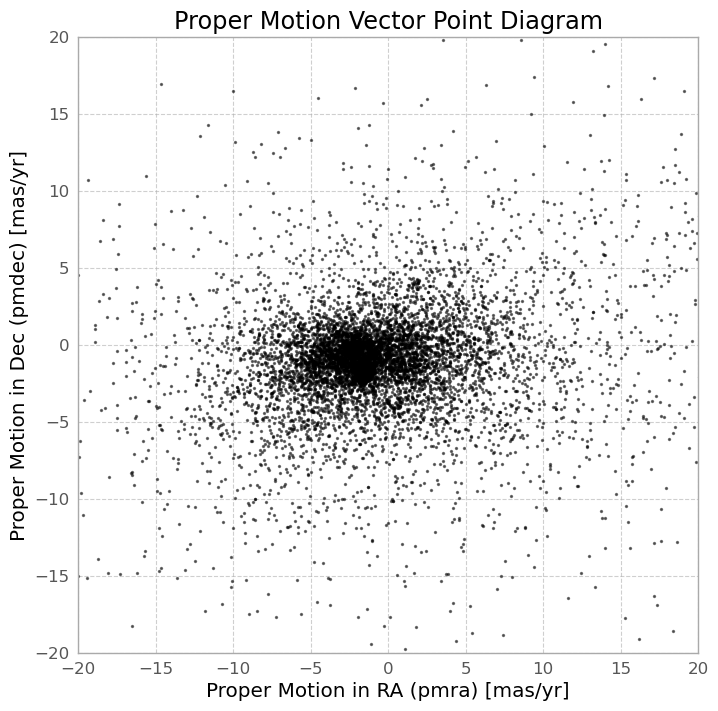

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('gaia_results.csv')
plt.figure(figsize=(8, 8))
plt.scatter(df['pmra'], df['pmdec'], s=2, color='black', alpha=0.5)
plt.title("Proper Motion Vector Point Diagram")
plt.xlabel("Proper Motion in RA (pmra) [mas/yr]")
plt.ylabel("Proper Motion in Dec (pmdec) [mas/yr]")
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Found 1997 potential cluster members!


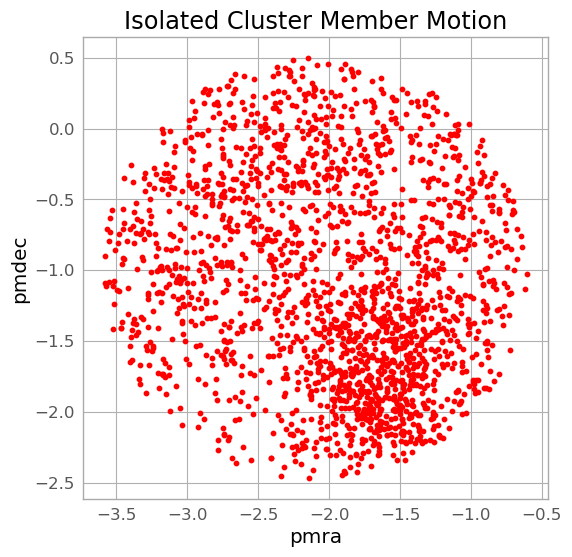

In [7]:
target_pmra = -2.1 
target_pmdec = -1
radius = 1.5 
members = df[((df['pmra'] - target_pmra)**2 + (df['pmdec'] - target_pmdec)**2) < radius**2]
members.to_csv('confirmed_cluster_members.csv', index=False)

print(f"Found {len(members)} potential cluster members!")
plt.figure(figsize=(6,6))
plt.scatter(members['pmra'], members['pmdec'], color='red', s=10)
plt.title("Isolated Cluster Member Motion")
plt.xlabel("pmra")
plt.ylabel("pmdec")
plt.grid(True)
plt.show()

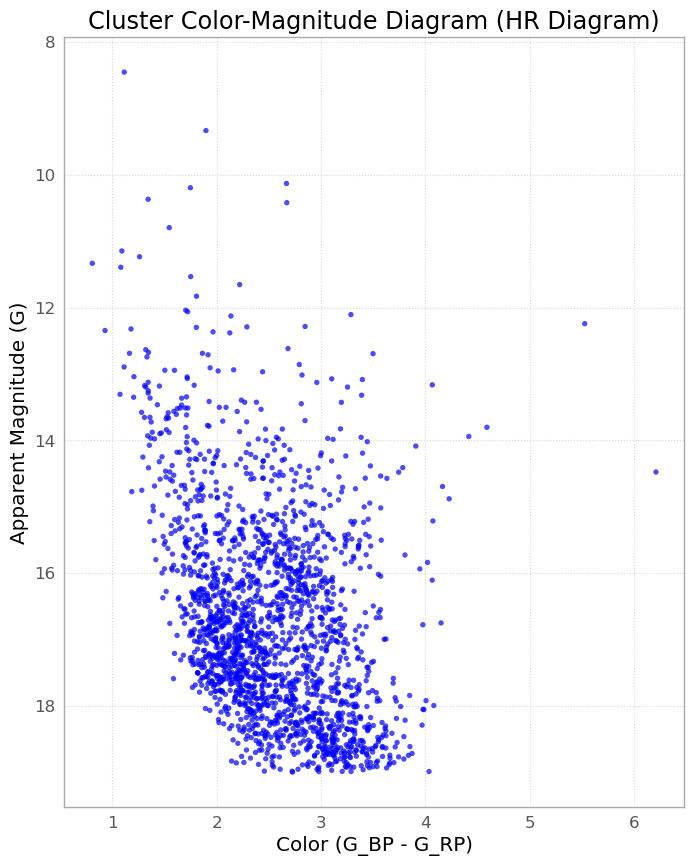

In [8]:
confirmed_df = pd.read_csv('confirmed_cluster_members.csv')
plt.figure(figsize=(8, 10))
plt.scatter(confirmed_df['bp_rp'], confirmed_df['phot_g_mean_mag'],c='blue', s=15, alpha=0.7, edgecolors='none')
plt.gca().invert_yaxis()

plt.title("Cluster Color-Magnitude Diagram (HR Diagram)")
plt.xlabel("Color (G_BP - G_RP)")
plt.ylabel("Apparent Magnitude (G)")

plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

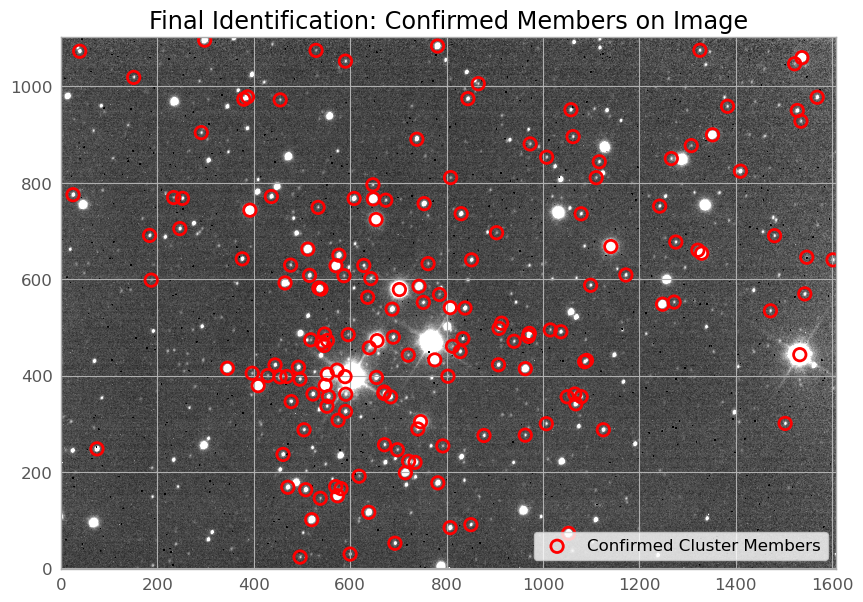

In [12]:
import numpy as np
hdul = fits.open('Berk_i.wcs.proc (1).fits')
wcs = WCS(hdul[0].header)
image_data = hdul[0].data
world_coords = members_df[['ra', 'dec']].values
pixel_x, pixel_y = wcs.wcs_world2pix(world_coords[:,0], world_coords[:,1], 0)
mask = (pixel_x >= 0) & (pixel_x < image_data.shape[1]) & \
       (pixel_y >= 0) & (pixel_y < image_data.shape[0])

filtered_x = pixel_x[mask]
filtered_y = pixel_y[mask]
plt.figure(figsize=(10, 10))
norm = ImageNormalize(image_data, interval=ZScaleInterval())

plt.imshow(image_data, cmap='gray', norm=norm, origin='lower')
plt.scatter(filtered_x, filtered_y, s=80, edgecolors='red', 
            facecolors='none', lw=2, label='Confirmed Cluster Members')

plt.title("Final Identification: Confirmed Members on Image")
plt.legend()
plt.show()

hdul.close()

Photometry

In [5]:
import pandas as pd
confirmed_df = pd.read_csv('confirmed_cluster_members.csv')
print(confirmed_df.columns)
ra,dec

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'bp_rp', 'ruwe'],
      dtype='object')
